# 実験Ⅳ－２　時系列データの分析 - 予習課題

## 課題内容
1. サンプルデータ「example02_01_2026.wav」を使用
2. 時系列データ（階差系列）y_diffの開始から1秒間のデータを分析
3. 平均 $\mu$ と分散 $\gamma_0$ を推定
4. 自己共分散関数 $\gamma_k$ と自己相関関数 $\rho_k$ を推定
5. グループワーク用時系列データ候補を検討

新潟大学工学部工学科　電子情報通信プログラム

## 準備

In [13]:
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore') #警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib #日本語化matplotlib
sns.set(font="IPAexGothic") #日本語フォント設定

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 68.6 MB/s eta 0:00:00:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=6fe402585279a30c4d44b1bd48256dfae99cbb562bd483edaabef9d1b6b91e02
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


## サンプルデータの読み込み

WAV形式の音響データ（モノラル）を読込
ファイル: data/example02_01_2026.wav

In [14]:
import wave
import os

# Colabの場合のファイル読み込み処理
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Google Colabで実行中です')
    print('\n=== Google Driveのマウント ===')
    print('Google Driveをマウントして、ローカルファイルにアクセスします')
    
    # Google Driveをマウント
    drive.mount('/content/drive')
    
    # Google Drive内のパスを指定
    # 例: /content/drive/My Drive/folder_name/example02_01_2026.wav
    filepath = '/content/drive/My Drive/電子情報通信実験Ⅳ/data/example02_01_2026.wav'
    filename = 'example02_01_2026.wav'
    
    print('\nマウント完了')
    print('パス: {}'.format(filepath))
else:
    # ローカル環境での処理
    print('ローカル環境で実行中です')
    data_dir = './data'
    filename = 'example02_01_2026.wav'
    filepath = os.path.join(data_dir, filename)

wf = wave.open(filepath, mode='rb')
buf = wf.readframes(-1)
ch  = wf.getnchannels()
fs  = wf.getframerate()
nf  = wf.getnframes()
y   = np.frombuffer(buf, dtype='int16')

print('ファイル: {}'.format(filename))
print('チャンネル数 = {:d} ch'.format(ch))
print('標本化周波数 = {:f} Hz'.format(fs))
print('総フレーム数 = {:d}'.format(nf))
print('長さ = {:f} 秒'.format(nf/fs))

# ステレオならモノラルに変換
if ch == 2:
    y = y.reshape(-1, 2)    # 2列（左・右）に変形
    y = y.mean(axis=1).astype('int16')  # 左右平均してint16に戻す
    print('ステレオをモノラルに変換しました')

Google Colabで実行中です

=== Google Driveのマウント ===
Google Driveをマウントして、ローカルファイルにアクセスします
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

マウント完了
パス: /content/drive/My Drive/電子情報通信実験Ⅳ/data/example02_01_2026.wav
ファイル: example02_01_2026.wav
チャンネル数 = 2 ch
標本化周波数 = 48000.000000 Hz
総フレーム数 = 240000
長さ = 5.000000 秒
ステレオをモノラルに変換しました


## 時系列データをpandas.DataFrameオブジェクトに変換

pandas ライブラリの DataFrame オブジェクトに変換

- t: 時刻
- y: データの値

以下では0～1秒までのデータを抽出

In [15]:
t = np.linspace(0, nf/fs, nf)
df_full = pd.DataFrame({'t': t, 'y': y})

# 0～1秒のデータを抽出
tstart = 0.0
tend   = 1.0
df_original = df_full[(df_full['t'] >= tstart) & (df_full['t'] < tend)]
print('\n原系列（0～1秒）のサンプル数: {}'.format(len(df_original)))
print('\n原系列の最初の10行:')
display(df_original.head(10))


原系列（0～1秒）のサンプル数: 48000

原系列の最初の10行:


,t,y
0,0.000000,5820
1,0.000021,3771
2,0.000042,437
3,0.000063,-409
4,0.000083,-3912
5,0.000104,-8983
6,0.000125,-7257
7,0.000146,-2583
8,0.000167,-1170
9,0.000188,1540


## 原系列のプロット

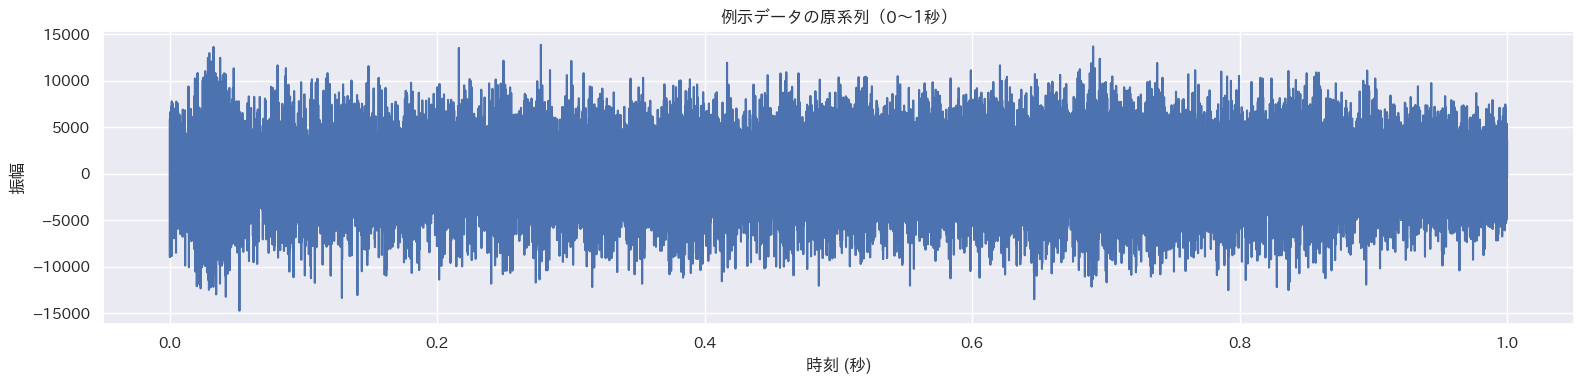

In [16]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_original['t'], df_original['y'])
ax.set_xlabel('時刻 (秒)')
ax.set_ylabel('振幅')
ax.set_title('例示データの原系列（0～1秒）')
plt.grid(True)
plt.tight_layout()

## 原系列のヒストグラム

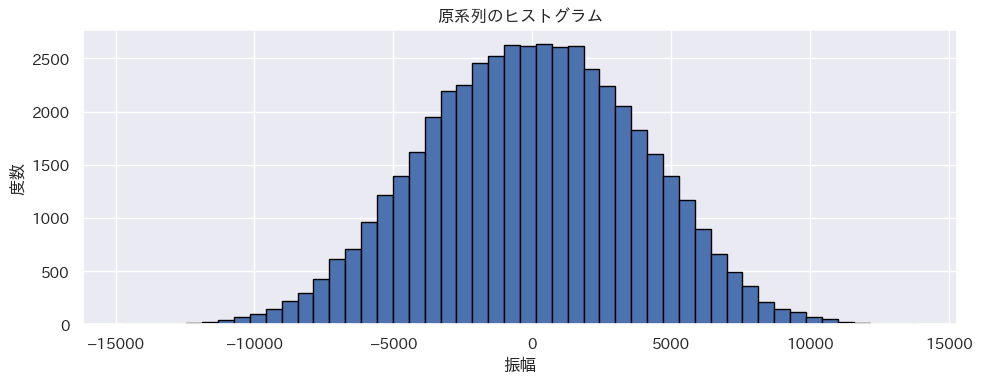

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_original['y'], bins=50, edgecolor='black')
ax.set_xlabel('振幅')
ax.set_ylabel('度数')
ax.set_title('原系列のヒストグラム')
plt.tight_layout()

## 階差系列の計算

ひとつ前の値との差分をとった系列を階差系列とよぶ。

$\Delta y_n = y_{n} - y_{n-1}$

In [18]:
# 階差系列を計算
df_original['y_diff'] = df_original['y'].diff()

# NaNを削除
y_diff_series = df_original['y_diff'].dropna()

print('階差系列のサンプル数: {}'.format(len(y_diff_series)))
print('\n階差系列の最初の10行:')
display(y_diff_series.head(10))

階差系列のサンプル数: 47999

階差系列の最初の10行:


,y_diff
1,-2049.0
2,-3334.0
3,-846.0
4,-3503.0
5,-5071.0
6,1726.0
7,4674.0
8,1413.0
9,2710.0
10,4019.0


## 階差系列のプロット

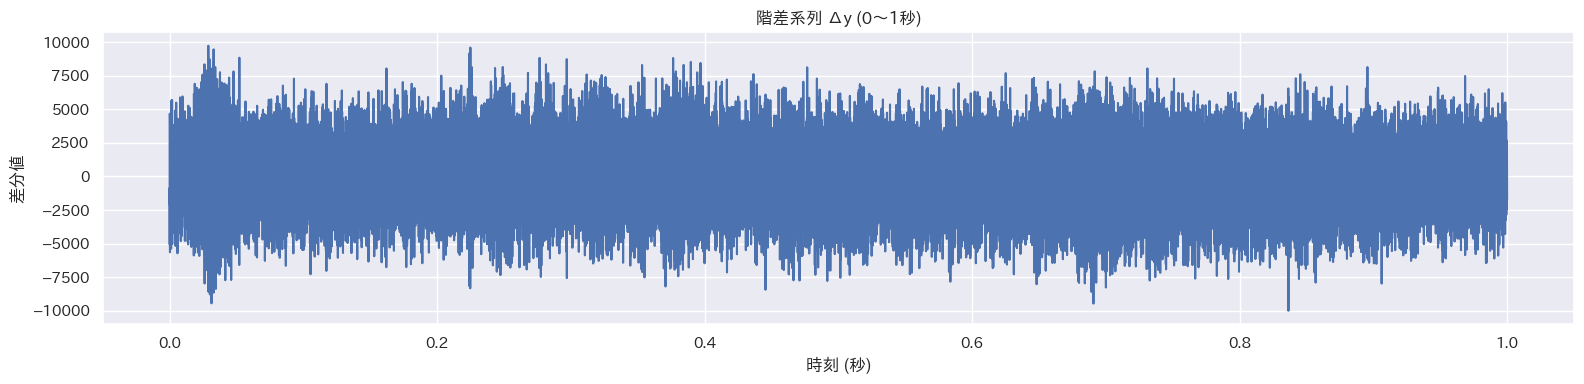

In [19]:
# 階差系列の時刻データを取得
t_diff = df_original['t'].iloc[1:].values

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(t_diff, y_diff_series.values)
ax.set_xlabel('時刻 (秒)')
ax.set_ylabel('差分値')
ax.set_title('階差系列 Δy (0～1秒)')
plt.grid(True)
plt.tight_layout()

## 階差系列のヒストグラム

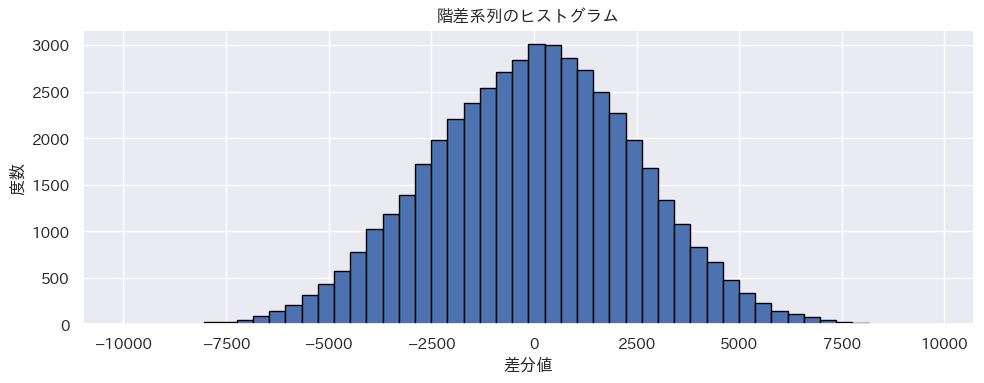

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_diff_series.values, bins=50, edgecolor='black')
ax.set_xlabel('差分値')
ax.set_ylabel('度数')
ax.set_title('階差系列のヒストグラム')
plt.tight_layout()

# 課題1: 平均 $\mu$ と分散 $\gamma_0$ の推定

定常性を仮定して、階差系列の平均と分散を推定

- mean(): 標本平均を計算
- var(): 標本分散を計算

pandas.DataFrame オブジェクトのvar() メソッドのオプションで
- ddof = 0 とすると N で割る最尤推定
- ddof = 1 とすると (N-1)で割る不偏推定 ※デフォルト

In [21]:
# 不偏推定
mu_unbiased = y_diff_series.mean()
gamma0_unbiased = y_diff_series.var(ddof=1)

# 最尤推定
mu_mle = y_diff_series.mean()
gamma0_mle = y_diff_series.var(ddof=0)

print('='*60)
print('課題1: 平均μと分散γ₀の推定')
print('='*60)
print('\n対象データ: 階差系列 y_diff (0～1秒)')
print('サンプル数 N = {}'.format(len(y_diff_series)))
print('\n【不偏推定】')
print('  平均 μ = {:.10f}'.format(mu_unbiased))
print('  分散 γ₀ = {:.10f}'.format(gamma0_unbiased))
print('\n【最尤推定】')
print('  平均 μ = {:.10f}'.format(mu_mle))
print('  分散 γ₀ = {:.10f}'.format(gamma0_mle))

課題1: 平均μと分散γ₀の推定

対象データ: 階差系列 y_diff (0～1秒)
サンプル数 N = 47999

【不偏推定】
  平均 μ = -0.1295443624
  分散 γ₀ = 6303989.5000000000

【最尤推定】
  平均 μ = -0.1295443624
  分散 γ₀ = 6303858.5000000000


# 課題2: 自己共分散関数 $\gamma_k$ と自己相関関数 $\rho_k$ の推定

定常性を仮定して、自己共分散関数と自己相関関数を推定

## 方法1: pandas.Series の cov() と corr() を使用

In [22]:
print('\n' + '='*60)
print('課題2-1: pandas.Series を使用した推定')
print('='*60)

nlags = 40
print('\nLag k | 自己共分散 γₖ      | 自己相関関数 ρₖ')
print('-'*60)

gamma_k_list = []
rho_k_list = []

for lag in range(nlags + 1):
    gammak = y_diff_series.cov(y_diff_series.shift(lag))
    rhok = y_diff_series.corr(y_diff_series.shift(lag))
    gamma_k_list.append(gammak)
    rho_k_list.append(rhok)
    print('  {:2d}  | {: .10e}  | {: .10f}'.format(lag, gammak, rhok))


課題2-1: pandas.Series を使用した推定

Lag k | 自己共分散 γₖ      | 自己相関関数 ρₖ
------------------------------------------------------------
   0  |  6.3040257358e+06  |  1.0000000000
   1  |  3.4611555199e+06  |  0.5490340994
   2  | -3.6305284189e+05  | -0.0575901854
   3  | -1.4104448587e+06  | -0.2237312560
   4  | -2.7065521516e+06  | -0.4293257673
   5  | -3.9864916326e+06  | -0.6323700964
   6  | -2.6983844800e+06  | -0.4280331851
   7  | -5.8293576334e+05  | -0.0924707258
   8  |  1.0481971579e+06  |  0.1662737922
   9  |  2.8772146337e+06  |  0.4564053827
  10  |  3.4801271154e+06  |  0.5520525623
  11  |  2.0351942268e+06  |  0.3228363284
  12  |  3.3816561618e+05  |  0.0536415471
  13  | -9.3636045128e+05  | -0.1485317598
  14  | -2.2524571126e+06  | -0.3573120364
  15  | -2.8540578222e+06  | -0.4527395222
  16  | -2.1909667591e+06  | -0.3475488511
  17  | -8.9367707732e+05  | -0.1417606453
  18  |  7.6752605338e+05  |  0.1217483381
  19  |  2.5375602490e+06  |  0.4025271086
  20  |  3.140

## 方法2: statsmodels ライブラリを使用

In [24]:
import statsmodels.api as sm
from statsmodels.tsa import stattools

print('\n' + '='*60)
print('課題2-2: statsmodels を使用した推定')
print('='*60)

# 自己共分散関数（不偏推定）
print('\n【自己共分散関数 γₖ（不偏推定）】')
# statsmodelsのバージョン差分に対応
try:
    y_acovf_unbiased = stattools.acovf(y_diff_series, adjusted=True, nlag=nlags)
except TypeError:
    # 旧バージョン向けフォールバック
    y_acovf_unbiased = stattools.acovf(y_diff_series, unbiased=True)[:nlags+1]

print('\nLag k | 自己共分散 γₖ')
print('-'*40)
for lag in range(min(nlags + 1, len(y_acovf_unbiased))):
    print('  {:2d}  | {: .10e}'.format(lag, y_acovf_unbiased[lag]))

# 自己相関関数（adjusted推定）
print('\n【自己相関関数 ρₖ（調整推定）】')
try:
    y_acf_adjusted = stattools.acf(y_diff_series, adjusted=True, nlags=nlags)
except TypeError:
    # 旧バージョン向けフォールバック
    y_acf_adjusted = stattools.acf(y_diff_series, unbiased=True, nlags=nlags)

print('\nLag k | 自己相関関数 ρₖ')
print('-'*40)
for lag in range(min(nlags + 1, len(y_acf_adjusted))):
    print('  {:2d}  | {: .10f}'.format(lag, y_acf_adjusted[lag]))


課題2-2: statsmodels を使用した推定

【自己共分散関数 γₖ（不偏推定）】

Lag k | 自己共分散 γₖ
----------------------------------------
   0  |  6.3038943992e+06
   1  |  3.4610834110e+06
   2  | -3.6304527033e+05
   3  | -1.4104154612e+06
   4  | -2.7064957448e+06
   5  | -3.9864085538e+06
   6  | -2.6983282425e+06
   7  | -5.8292361630e+05
   8  |  1.0481753089e+06
   9  |  2.8771546773e+06
  10  |  3.4800545963e+06
  11  |  2.0351518161e+06
  12  |  3.3815857126e+05
  13  | -9.3634092537e+05
  14  | -2.2524101505e+06
  15  | -2.8539983252e+06
  16  | -2.1909210847e+06
  17  | -8.9365844806e+05
  18  |  7.6751005907e+05
  19  |  2.5375073636e+06
  20  |  3.1400850225e+06
  21  |  2.0840354720e+06
  22  |  4.9255638859e+05
  23  | -1.0902127522e+06
  24  | -2.6058083371e+06
  25  | -2.9496996432e+06
  26  | -1.8539545470e+06
  27  | -5.5522476595e+05
  28  |  9.1082244909e+05
  29  |  2.7671448577e+06
  30  |  3.2750724378e+06
  31  |  1.7614176484e+06
  32  |  2.3760690274e+04
  33  | -1.2677895249e+06
  34  | -

## コレログラム（自己相関関数のプロット）

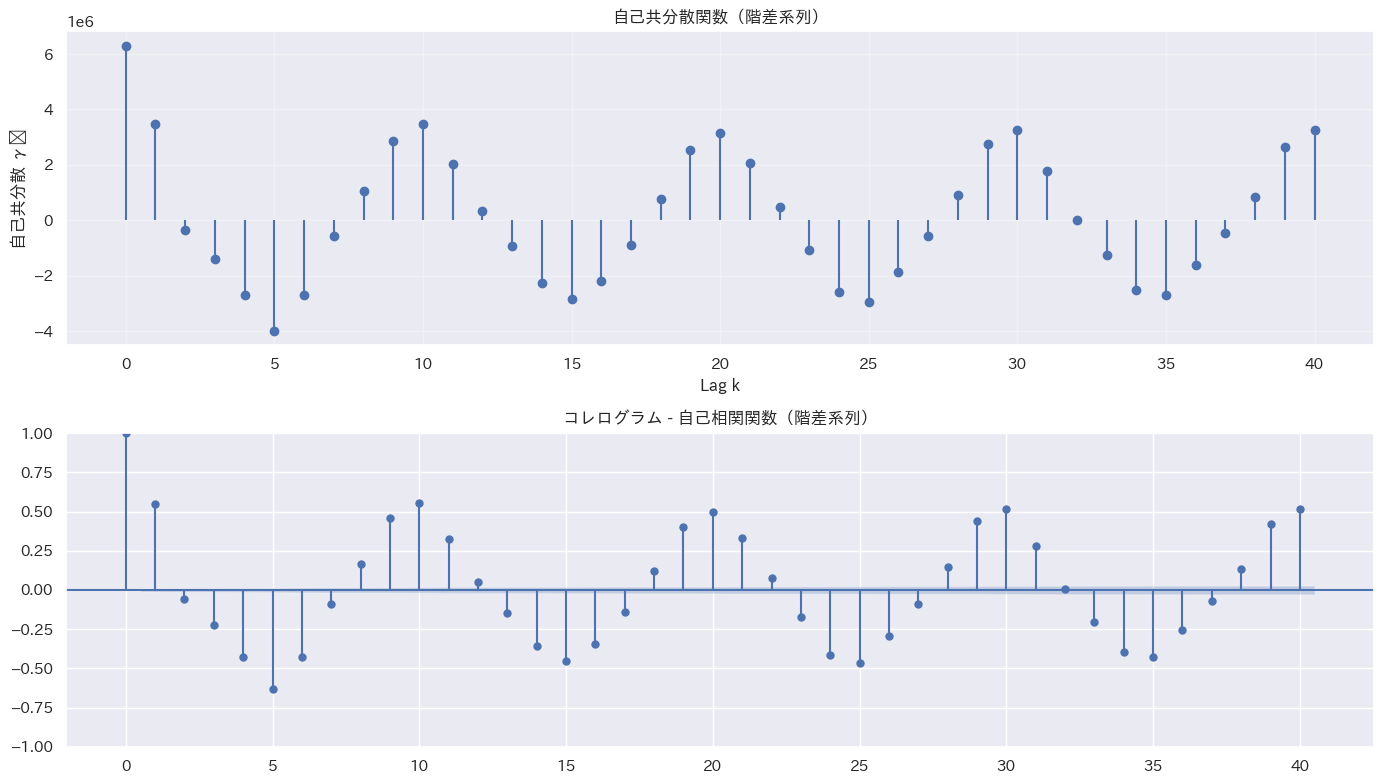

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 自動共分散関数のプロット
axes[0].stem(range(len(y_acovf_unbiased)), y_acovf_unbiased, basefmt=' ')
axes[0].set_xlabel('Lag k')
axes[0].set_ylabel('自己共分散 γₖ')
axes[0].set_title('自己共分散関数（階差系列）')
axes[0].grid(True, alpha=0.3)

# 自己相関関数のプロット（コレログラム）
sm.graphics.tsa.plot_acf(y_diff_series, lags=nlags, ax=axes[1])
axes[1].set_title('コレログラム - 自己相関関数（階差系列）')

plt.tight_layout()

# グループワーク用時系列データ候補

## グループワークに利用可能な時系列データの候補

### 1. **オープンデータの活用**

#### 気象・環境データ
- **気象データ**: 気象庁のオープンデータ
  - 気温、降水量、湿度の日別・時別データ
  - 年単位の長期時系列で定常性の検討が可能
  - 例: 新潟地域の日平均気温

- **太陽放射データ**: 国立天文台や世界気象機関のデータ
  - 太陽黒点数の月別データ
  - 全球放射量（既存ファイル: solar_dataset.csv）

- **空気質データ**: 環境省のPM2.5、NO₂など
  - 時間別、日別のデータ提供

#### 経済・金融データ
- **株価データ**: Yahoo Finance, Alpha Vantage APIなど
  - 日次終値、取引量
  - 複数年間のデータで周期性・トレンドを検討

- **為替レート**: 日本銀行、世界銀行
  - 日次、週次レート

- **GDP, インフレ率**: OECD, IMFのデータベース
  - 四半期または年単位

#### 交通・エネルギーデータ
- **電力消費量**: 電力会社のオープンデータ
  - 日別、時間別の需要データ
  - 季節変動と週次変動が明確

- **交通量**: 国土交通省のデータ
  - 高速道路の通行台数
  - 曜日・季節による周期性

### 2. **公開論文からのデータ**

- **Kaggleコンペティション**
  - 様々な時系列予測タスクのデータセット
  - 例: タクシー需要、エネルギー使用量

- **UCI Machine Learning Repository**
  - 複数の時系列分類・回帰データセット

- **学術論文のデータセット**
  - Github, Zenodoで公開されているものが多い

### 3. **実測データの取得**

#### 研究室で取得可能なセンサデータ
- **温度・湿度センサ**
  - 研究室内の環境測定
  - 複数箇所での同時測定が可能
  - 数日～数週間の連続測定

- **照度センサ**
  - 窓際での日照変動
  - 天候による急激な変化が観測できる

- **音声データ**
  - 既存ファイル: example02_01_2026.wav（ファン雑音）
  - 新規に収録可能

- **IMUセンサ** (加速度、角速度)
  - スマートフォン, Raspberry Piで測定可能
  - 手書き文字、歩行パターンなど

#### 個人レベルで取得可能なデータ
- **健康データ**
  - 心拍数, 睡眠時間, 歩数
  - スマートウォッチから取得可能
  - 数週間～数ヶ月の個人データで周期性検討

- **SNSアクティビティ**
  - ツイート数, いいね数
  - 曜日・時間帯パターンの分析

- **ゲーム用入力デバイス**
  - コントローラの加速度データ
  - 操作パターンの時系列化

### 4. **推奨される分析対象**

| データ類型 | 長所 | 短所 | 推奨度 |
|----------|------|------|--------|
| 太陽放射量 | 既存ファイル有、明確な周期性 | データ前処理最小限 | ★★★★★ |
| 気温データ | 長期間のデータ入手容易、季節性顕著 | トレンド成分が大きい | ★★★★☆ |
| 株価データ | ファイナンス知識獲得、興味深い | 非定常性が強い | ★★★☆☆ |
| センサデータ（温度） | 実装が簡単、定常性が高い | 測定期間が短くなる | ★★★★☆ |
| 心拍数 | 個人データで興味深い、容易取得 | 定常性が低い可能性 | ★★★☆☆ |
| 電力消費量 | 周期性が明確、政策的な価値 | 規模が大きい、精度要求高 | ★★★★☆ |

## 分析結果のまとめ

このノートブックでは、以下の分析を実施した：

1. **データの読み込み**: example02_01_2026.wav から0～1秒間のデータを抽出
2. **階差系列の計算**: 原系列から1階の階差を計算
3. **平均と分散の推定**: 不偏推定と最尤推定を実施
4. **自己共分散と自己相関の推定**: 
   - pandas.Series を使用した直接計算
   - statsmodels ライブラリを使用した推定
5. **可視化**: 自動共分散関数のプロット、コレログラム表示
6. **グループワーク用データ候補**: 複数分野のデータソースと取得方法を提案

### 実行後のステップ
1. このノートブックを実行
2. 出力結果を確認
3. 結果をファイル（CSV, Markdown）に出力
4. グループメンバーで分析データを選定・討論